# Proyek Analisis Data: Bike Sharing dataset
- **Nama:** Devi Ema Dewiyanti
- **Email:** deviemadewi@gmail.com
- **ID Dicoding:** CDCC899D6X0680

## Menentukan Pertanyaan Bisnis

- Bagaimana pola permintaan layanan bike sharing berdasarkan dimensi waktu, secara harian dalam periode 2011 hingga 2012?
- Bagaimana pengaruh faktor eksternal seperti kondisi cuaca dan musim terhadap jumlah penyewaan sepeda, dalam periode 2011 hingga 2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Data ini memiliki struktur data multivariat yang mencakup informasi waktu, kondisi lingkungan, dan tipe pengguna
- Variabel target utama adalah jumlah penyewaan (cnt), yang mana dipengaruhi oleh berbagai faktor seperti cuaca, musim, dan tipe pengguna.
- Berikut penjelasan beberapa kolom dalam dataset tersebut:
  - instan: nomor urut baris
  - dteday: tanggal data tersebut diambil
  - season: musim yang dimasukkan dalam bentuk angka (1. musim semi, 2. musim panas, 3. musim gugur, 4. musim dingin)
  - yr: tahun data (0. tahun 2011 dan 1. tahun 2012)
  - mnth: bulan (angka 1 untuk januari, dst hingga bulan ke 12)
  - hr: jam (dalam 24 jam)
  - holiday: hari libur (1: ya, 0: tidak)
  - weekday: hari rentan seminggu (0. Senin, dst hingga 6. Minggu)
  - workingday: hari kerja (1: ya, 0: tidak)
  - weathersit: kondisi cuaca dalam bentuk angka (1. cerah, 2. berawan, 3. hujan)
  - temp: suhu aktual (0 hingga 1)
  - atemp: suhu yang sedang dirasakan
  - hum: kelembapan (0 hingga 1)
  - windspeed: kecepatan angin (0 hingga 1)
  - casual: jumlah pengguna casual (tanpa registrasi)
  - registered: jumlah pengguna terdaftar (sudah melakukan registrasi)
  - cnt: jumlah total penyewa

### Assessing Data

Menilai data day

In [3]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [4]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [5]:
print("Jumlah Duplikasi: ", day_df.duplicated().sum())

Jumlah Duplikasi:  0


In [6]:
day_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


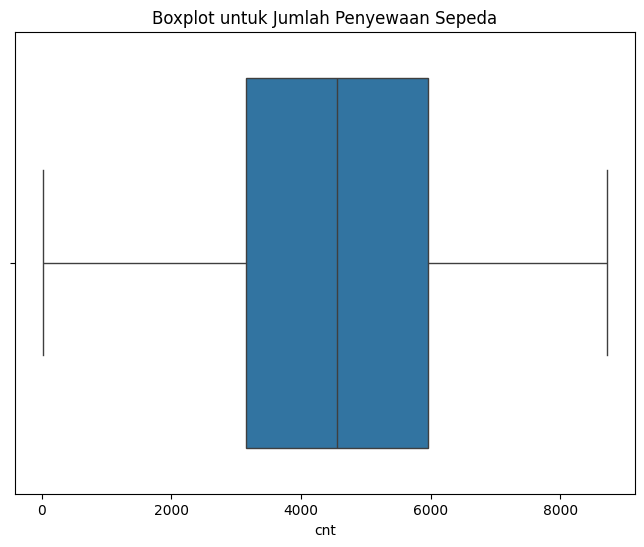

In [7]:
#membuat boxplot untuk mengecek outlier
plt.figure(figsize=(8, 6))
sns.boxplot(x=day_df['cnt'])
plt.title('Boxplot untuk Jumlah Penyewaan Sepeda')
plt.show()

**Insight:**
- Tidak terdapat missing value maupun duplikasi pada dataset ini
- Tidak terdapat outlier pula setelah mengecek melalui boxplot
- Format penulisan beberapa kolom yang sulit dipahami (instant, dtebay, yr, mnth, hr, weathersit, cnt)
- Beberapa tipe data dalam dataset tersebut:
  - kolom numerik: seperti season, yr, mnth, dll adalah tipe data integer
  - kolom float: seperti temp, atemp, hum, dan windspeed menggunakan tipe float64
  - kolom objek(string): dteday, kemungkinan pada kolom ini mengalami Inaccurate value

### Cleaning Data

In [8]:
#mengubah tipe data 'dteday'
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [9]:
#menghapus kolom 'holiday' karena sudah ada kolom 'workingday'
day_df.drop(['holiday'], axis=1, inplace=True)

In [10]:
#rename kolom
day_df.rename(columns={
    "instant": "id",
    "dteday": "date",
    "yr": "year",
    "mnth": "month",
    "hr": "hour",
    "weathersit": "weather",
    "cnt": "count"
}, inplace=True)

day_df.head()

,id,date,season,year,month,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,1,0,1,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [11]:
def change_year(x):
    if x == 0:
        return 2011
    else:
        return 2012

day_df['year'] = day_df['year'].apply(change_year)
day_df.head()

,id,date,season,year,month,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,1,2011,1,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,2011,1,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,2011,1,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,2011,1,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,2011,1,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [12]:
month_change = {1: 'Januari', 2: 'Febuari', 3: 'Maret', 4:'April', 5:'Mei', 6:'Juni', 7:'Juli',
                8:'Agustus', 9:'September', 10:'Oktober', 11:'November', 12:'Desember'}

day_df['month'] = day_df['month'].map(month_change)
day_df.head()

,id,date,season,year,month,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,1,2011,Januari,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,2011,Januari,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,2011,Januari,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,2011,Januari,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,2011,Januari,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [13]:
day_change = {0: 'Senin', 1: 'Selasa', 2: 'Rabu', 3: 'Kamis', 4:'Jumat', 5:'Sabtu', 6:'Minggu'}

day_df['weekday'] = day_df['weekday'].map(day_change)
day_df.head()

,id,date,season,year,month,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,1,2011,Januari,Minggu,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,2011,Januari,Senin,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,2011,Januari,Selasa,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,2011,Januari,Rabu,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,2011,Januari,Kamis,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [14]:
def change_workingday(x):
    if x == 0:
        return 'Holiday'
    else:
        return 'Working Day'

day_df['workingday'] = day_df['workingday'].apply(change_workingday)
day_df.head()

,id,date,season,year,month,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,1,2011,Januari,Minggu,Holiday,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,2011,Januari,Senin,Holiday,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,2011,Januari,Selasa,Working Day,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,2011,Januari,Rabu,Working Day,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,2011,Januari,Kamis,Working Day,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [15]:
def change_season(x):
    if x == 1:
        return 'Semi'
    elif x == 2:
        return 'Panas'
    elif x == 3:
        return 'Gugur'
    else:
        return 'Dingin'

day_df['season'] = day_df['season'].apply(change_season)
day_df.head()

,id,date,season,year,month,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,Semi,2011,Januari,Minggu,Holiday,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Semi,2011,Januari,Senin,Holiday,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Semi,2011,Januari,Selasa,Working Day,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Semi,2011,Januari,Rabu,Working Day,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Semi,2011,Januari,Kamis,Working Day,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [16]:
def change_weather(x):
    if x == 1:
        return 'Cerah'
    elif x == 2:
        return 'Berawan'
    else:
        return 'Hujan'

day_df['weather'] = day_df['weather'].apply(change_weather)
day_df.head()

,id,date,season,year,month,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
0,1,2011-01-01,Semi,2011,Januari,Minggu,Holiday,Berawan,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Semi,2011,Januari,Senin,Holiday,Berawan,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Semi,2011,Januari,Selasa,Working Day,Cerah,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Semi,2011,Januari,Rabu,Working Day,Cerah,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Semi,2011,Januari,Kamis,Working Day,Cerah,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Mengubah tipe data 'dteday' yang sebelumnya string menjadi datetime
- Menghapus kolom 'holiday' karena sudah ada kolom 'workingday' dan mengubah nama kolom agar lebih mudah dibaca dan dipahami
- Mengubah actual value untuk kolom:
  - year
  - month
  - weekday
  - workingday
  - season
  - weather

## Exploratory Data Analysis (EDA)

### Explore Bike Rental (day_df)



In [17]:
day_df.describe(include="all")

,id,date,season,year,month,weekday,workingday,weather,temp,atemp,hum,windspeed,casual,registered,count
count,731.000000,731,731,731.000000,731,731,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,NaN,12,7,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Gugur,NaN,Januari,Minggu,Working Day,Cerah,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,NaN,62,105,500,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,2011.500684,NaN,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,2011.000000,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,2011.000000,NaN,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,2012.000000,NaN,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,2012.000000,NaN,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,2012.000000,NaN,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Jumlah penyewa harian

In [18]:
day_df.groupby(by="weekday").agg({
    "date": "nunique",
    "casual": "sum",
    "registered": "sum",
    "count": ["max", "min", "mean", "sum"]
})

date  casual registered count                           
        nunique     sum        sum   max   min         mean     sum
weekday                                                            
Jumat       104   61460     423935  7804   431  4667.259615  485395
Kamis       104   57319     415729  8173   441  4548.538462  473048
Minggu      105  153852     323955  8714   627  4550.542857  477807
Rabu        104   57843     411266  7767   683  4510.663462  469109
Sabtu       104   78238     409552  8362  1167  4690.288462  487790
Selasa      105   70784     384719  7525    22  4338.123810  455503
Senin       105  140521     303506  8227   605  4228.828571  444027

Jumlah penyewa tiap bulan per tahun

In [19]:
day_df.groupby(by=["year", "month"]).agg({
    "date": "nunique",
    "casual": "sum",
    "registered": "sum",
    "count": ["max", "min", "mean", "sum"]
})

date casual registered count                           
               nunique    sum        sum   max   min         mean     sum
year month                                                               
2011 Agustus        31  28842     107849  5895  1115  4409.387097  136691
     April          30  22346      72524  5312   795  3162.333333   94870
     Desember       31   8448      78875  3940   705  2816.870968   87323
     Febuari        28   6242      41973  2927  1005  1721.964286   48215
     Januari        31   3073      35116  1985   431  1231.903226   38189
     Juli           31  36452     104889  6043  3285  4559.387097  141341
     Juni           30  30612     112900  5515  3767  4783.733333  143512
     Maret          31  12826      51219  3239   605  2065.967742   64045
     Mei            31  31050     104771  5805  2633  4381.322581  135821
     November       30  15594      86573  4486  1495  3405.566667  102167
     Oktober        31  25222      98289  5511   627  3984.225806  123511
     September      30  26545     100873  5423  1842  4247.266667  127418
2012 Agustus        31  43197     171306  7865  4549  6919.451613  214503
     April          30  38456     135768  7460  1027  5807.466667  174224
     Desember       31  13245     110468  6606   441  3990.741935  123713
     Febuari        29   8721      94416  5062  1529  3556.448276  103137
     Januari        31   8969      87775  4521  1301  3120.774194   96744
     Juli           31  41705     161902  8173  4459  6567.967742  203607
     Juni           30  43294     159536  8120  4127  6761.000000  202830
     Maret          31  31618     133257  8362  3194  5318.548387  164875
     Mei            31  44235     151630  8294  2843  6318.225806  195865
     November       30  21009     131655  6852  2277  5088.800000  152664
     Oktober        31  34538     164303  8156    22  6414.225806  198841
     September      30  43778     174795  8714  4073  7285.766667  218573

Jumlah penyewa berdasarkan cuaca dan musim

In [20]:
day_df.groupby(by=["season", "weather"]).agg({
    "date": "nunique",
    "casual": "sum",
    "registered": "sum",
    "count": ["max", "min", "mean", "sum"]
})

date  casual registered count                           
               nunique     sum        sum   max   min         mean     sum
season weather                                                            
Dingin Berawan      65   37876     264634  7852  1096  4654.000000  302510
       Cerah       103   90451     429036  8555  1495  5043.563107  519487
       Hujan        10    1455      18161  4639    22  1961.600000   19616
Gugur  Berawan      48   56407     194272  7582  1115  5222.479167  250679
       Cerah       136  167945     631498  8714  3285  5878.257353  799443
       Hujan         4    1739       9268  4459  1842  2751.750000   11007
Panas  Berawan      68   56714     231382  8362  1471  4236.705882  288096
       Cerah       113  146388     480598  8294  2028  5548.548673  626986
       Hujan         3     420       3087  1685   795  1169.000000    3507
Semi   Berawan      66   18779     136794  7836   605  2357.166667  155573
       Cerah       111   41562     270474  6312   431  2811.135135  312036
       Hujan         4     281       3458  2169   441   934.750000    3739

**Insight:**
- Penyewaan sepeda tertinggi terjadi di hari sabtu, dengan nilai rata-rata yaitu 4690.288462
- Pada tahun 2021 penyewaan tertinggi jatuh dibulan Juni, dengan rata-rata 4783.733333 dan jumlah pengguna 143512 orang.
Sedangkan di tahun selanjutnya 2012, penyewaan tertinggi jatuh dibulan September, dengan rata-rata 7285.766667 dan jumlah pengguna adalah 218573 orang
- Berdasarkan kondisi cuaca dan musim, penyewaan sepeda paling laris di musim gugur dengan cuaca cerah, jumlah pengguna adalah 799443 orang.
Sedangkan untuk penyewaan terendah jatuh di musim panas dengan cuaca hujan, jumlah pengguna adalah 3507 orang.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pola permintaan layanan bike sharing (penyewaan sepeda) secara harian, dalam periode 2011 hingga 2012?

In [21]:
sum_casual = day_df.groupby("weekday").casual.sum().sort_values(ascending=False).reset_index()
sum_casual

,weekday,casual
0,Minggu,153852
1,Senin,140521
2,Sabtu,78238
3,Selasa,70784
4,Jumat,61460
5,Rabu,57843
6,Kamis,57319


In [22]:
sum_registered = day_df.groupby("weekday").registered.sum().sort_values(ascending=False).reset_index()
sum_registered

,weekday,registered
0,Jumat,423935
1,Kamis,415729
2,Rabu,411266
3,Sabtu,409552
4,Selasa,384719
5,Minggu,323955
6,Senin,303506


In [23]:
daily_user = pd.merge(
    left=sum_casual,
    right=sum_registered,
    how="left",
    left_on="weekday",
    right_on="weekday"
)
daily_user

,weekday,casual,registered
0,Minggu,153852,323955
1,Senin,140521,303506
2,Sabtu,78238,409552
3,Selasa,70784,384719
4,Jumat,61460,423935
5,Rabu,57843,411266
6,Kamis,57319,415729


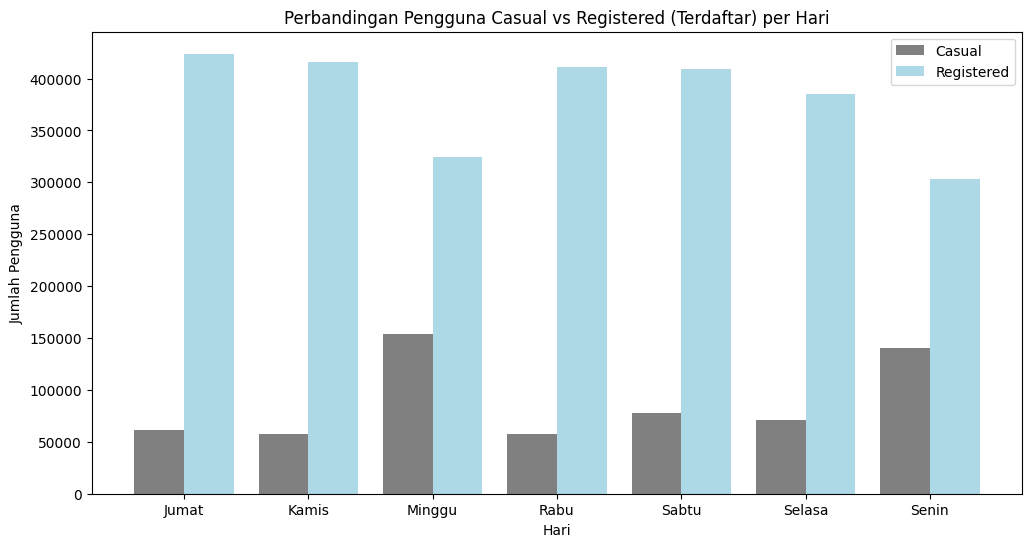

In [24]:
plt.figure(figsize=(12,6))

daily_users = day_df.groupby('weekday').agg({
    'casual': 'sum',
    'registered': 'sum'
})

x = range(len(daily_users.index))

plt.bar(x, daily_users['casual'], width=0.4, label='Casual', color='gray')
plt.bar([i + 0.4 for i in x], daily_users['registered'], width=0.4, label='Registered', color='lightblue')

plt.xticks([i + 0.2 for i in x], daily_users.index)
plt.title('Perbandingan Pengguna Casual vs Registered (Terdaftar) per Hari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Pengguna')
plt.legend()

plt.show()

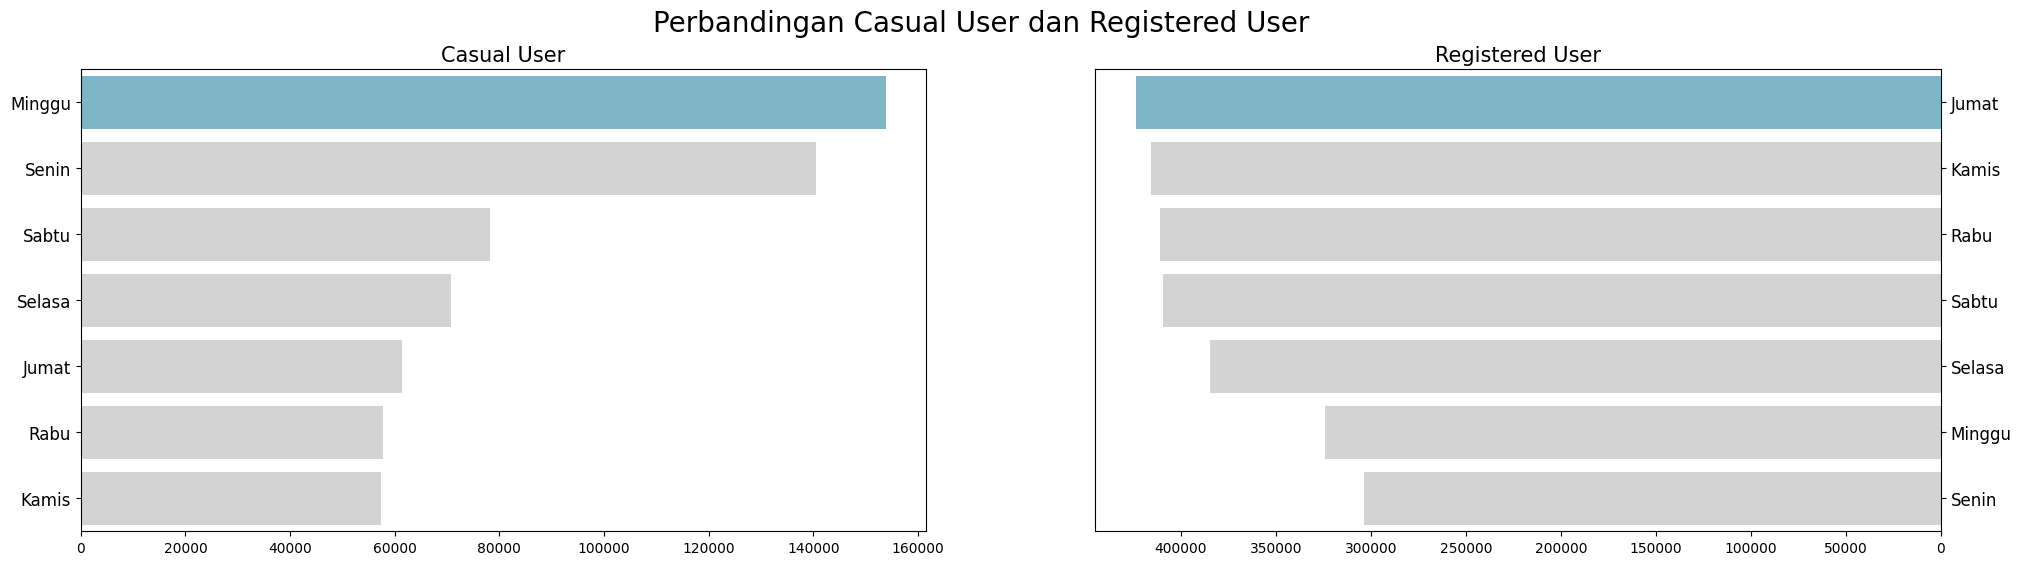

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="casual", y="weekday", data=sum_casual, palette=colors, hue="weekday", legend=False, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Casual User", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

sns.barplot(x="registered", y="weekday", data=sum_registered, hue="weekday", legend=False, palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Registered User", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Perbandingan Casual User dan Registered User", fontsize=20)
plt.show()

**Insight:**
- Casual User (Wisatawan/Rekreasi):
  - Penyewa ini cenderung menyewa pada hari minggu dan senin, dengan tren yang cenderung tinggi diakhir pekan (Sabtu-Minggu).
  - Senin berada di peringkat kedua tertinggi. Hal ini mungkin berkaitan dengan masa libur panjang atau perilaku pengguna yang memperpanjang waktu rekreasi mereka.
- Registered User (Pelanggan Tetap):
  - Puncak aktivitas terjadi pada hari kerja, terutama di hari Jumat, Kamis dan Rabu. Aktivitas juga menurun drastis di hari Minggu dan Senin.
  - Basis pengguna terdaftar (register) jauh lebih besar dan memberikan kontribusi transaksi lebih stabil dibanding pengguna kasual.
  - Berkebalikan dengan pengguna kasual, pengguna terdaftar pada hari senin justru menjadi hari dengan aktivitas terendah.

### Pertanyaan 2: Bagaimana pengaruh faktor eksternal terhadap jumlah penyewaan sepeda, dalam periode 2011 hingga 2012?

In [26]:
byweather = day_df.groupby("weather")['count'].sum().sort_values(ascending=False).reset_index()
byweather

,weather,count
0,Cerah,2257952
1,Berawan,996858
2,Hujan,37869


In [27]:
byseason = day_df.groupby("season")['count'].sum().sort_values(ascending=False).reset_index()
byseason

,season,count
0,Gugur,1061129
1,Panas,918589
2,Dingin,841613
3,Semi,471348


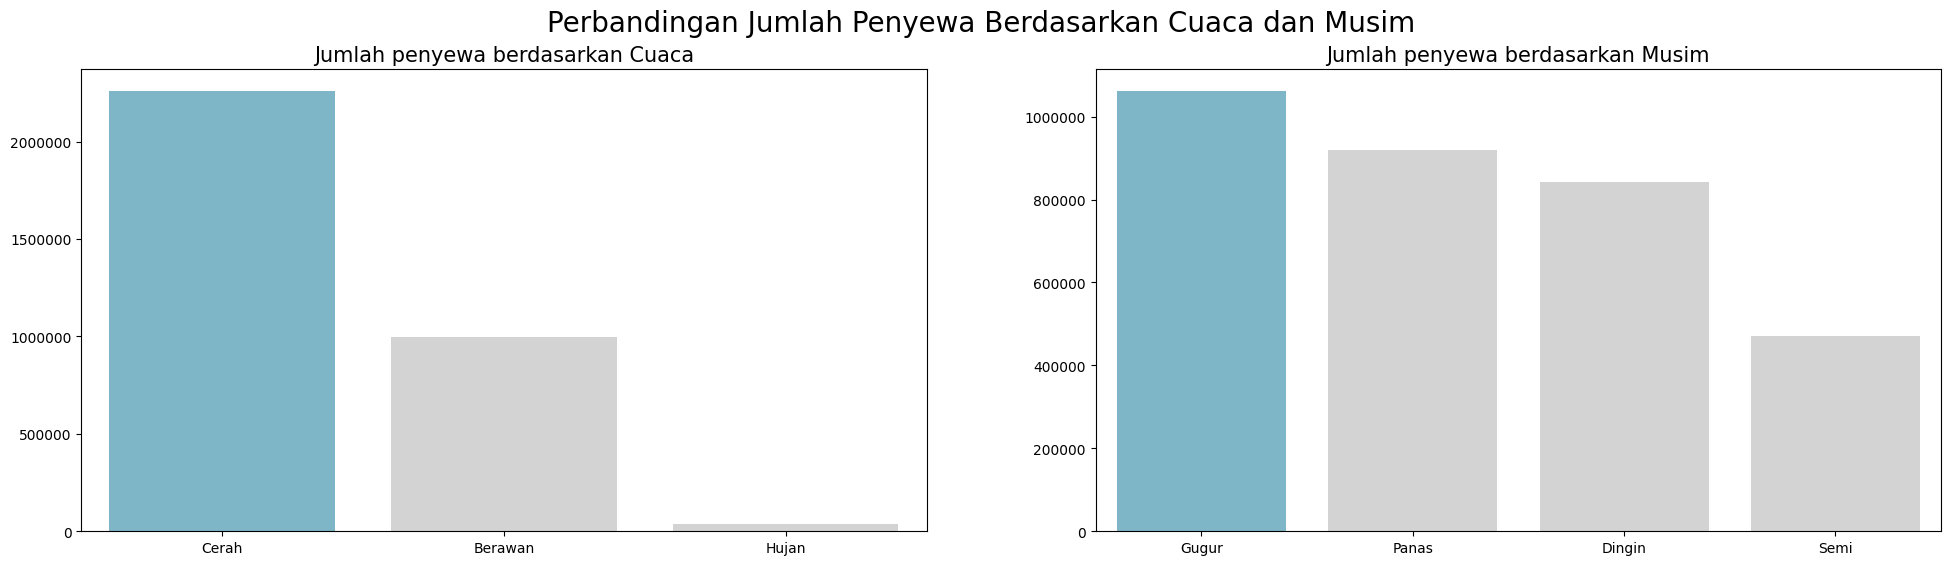

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))
color_weather = ["#72BCD4", "#D3D3D3", "#D3D3D3"]
color_season =  ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(y="count", x="weather", data=byweather.sort_values(by="count", ascending=False), palette=color_weather, hue="weather", legend=False, ax=ax[0])
ax[0].set_title("Jumlah penyewa berdasarkan Cuaca", loc="center", fontsize=15)
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].ticklabel_format(style='plain', axis='y')

sns.barplot(y="count", x="season", data=byseason.sort_values(by="count", ascending=False), palette=color_season, hue="season", legend=False, ax=ax[1])
ax[1].set_title("Jumlah penyewa berdasarkan Musim", loc="center", fontsize=15)
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].ticklabel_format(style='plain', axis='y')

plt.suptitle("Perbandingan Jumlah Penyewa Berdasarkan Cuaca dan Musim", fontsize=20)
plt.show()

**Insight:**
- Kondisi Cuaca:
  - Saat cuaca cerah, jumlah penyewa mencapai titik tertinggi (lebih dari 2.250.000).
  - Namun saat cuaca berawan, jumlah penyewa menurun secara signifikan menjadi 996.858 (penurunan lebih dari 50%)
  - Sedangkan saat cuaca hujan, jumlah penyewa sangat minim (37.869)
- Kondisi Musim:
  - Musim gugur menjadi periode paling populer dengan jumlah penyewa melampaui 1.000.000. Hal ini kemungkinan disebabkan oleh suhu yang sejuk, tidak terlalu panas dan tidak terlalu dingin, sangat nyaman untuk beraktivitas diluar.
  - Musim panas dan dingin memiliki performa yang cukup baik dan bersaing di angka 800.000 - 900.00. Namun disamping itu, jumlah penyewa dimusim dingin masih cukup tinggi (841.613).
  - Musim semi justru menunjukkan angka terendah (471.348), bahkan dibawah musim dingin.

## Analisis Lanjutan (Opsional)

**RFM ANALYSIS**

In [29]:
rfm_df = day_df.groupby(by="weekday", as_index=False).agg({
    "date": "max", # mengambil tanggal order terakhir
    "id": "nunique", # menghitung jumlah order
    "count": "sum" # menghitung jumlah revenue yang dihasilkan
})
rfm_df.columns = ["weekday", "max_order_timestamp", "frequency", "monetary"]

# menghitung kapan terakhir pelanggan melakukan transaksi (hari)
rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
recent_date = day_df["date"].dt.date.max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)

rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
rfm_df.head()

,weekday,frequency,monetary,recency
0,Jumat,104,485395,4
1,Kamis,104,473048,5
2,Minggu,105,477807,2
3,Rabu,104,469109,6
4,Sabtu,104,487790,3


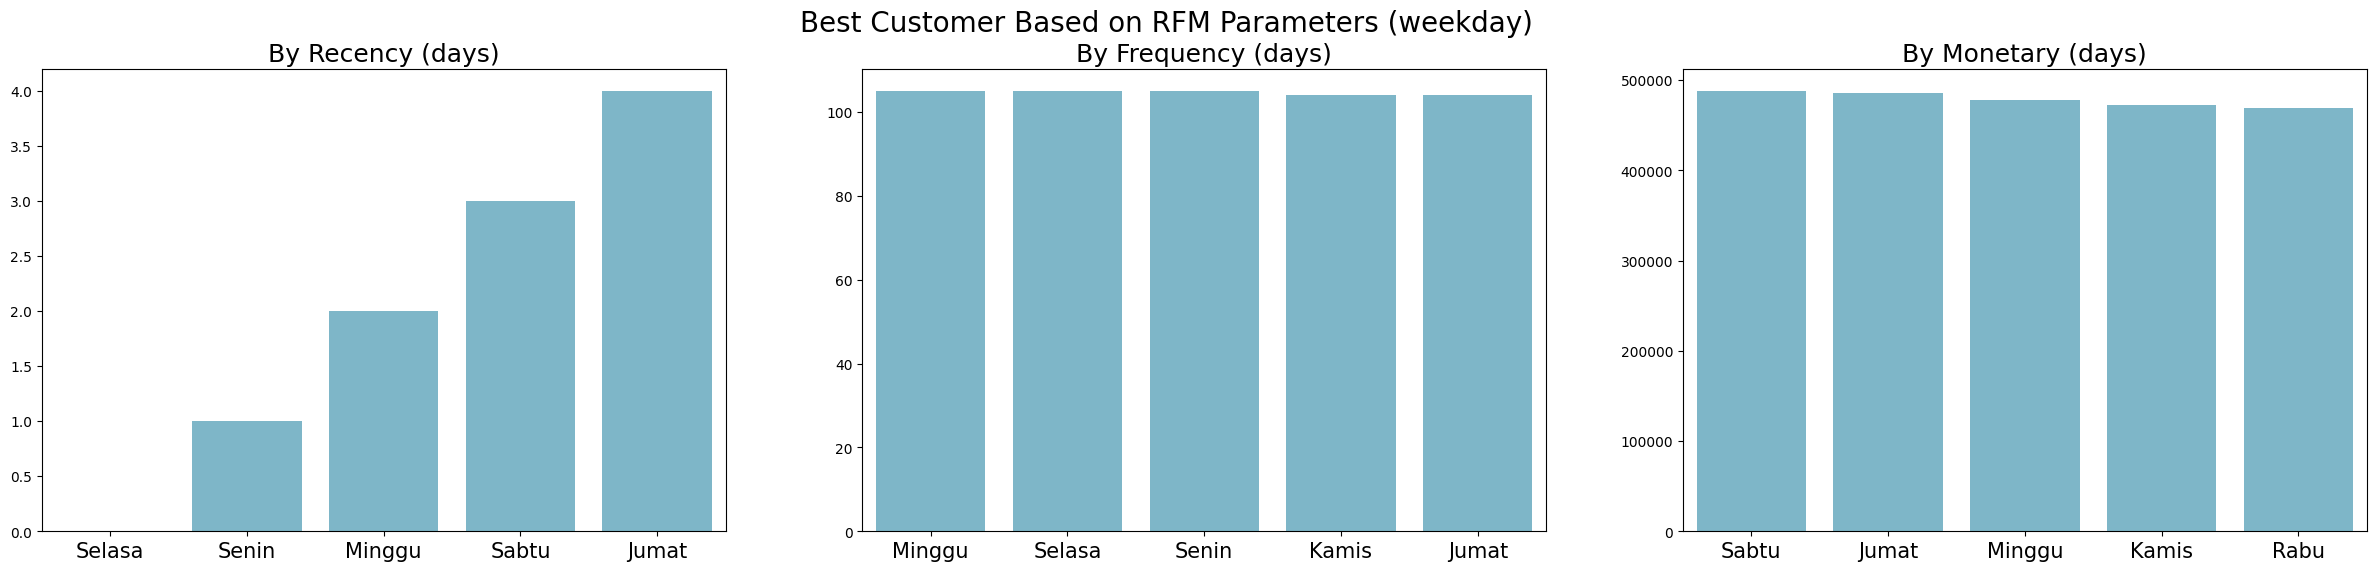

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

sns.barplot(y="recency", x="weekday", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, hue="weekday", ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=15)

sns.barplot(y="frequency", x="weekday", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, hue="weekday", ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency (days)", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15)

sns.barplot(y="monetary", x="weekday", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, hue="weekday", ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary (days)", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15)

plt.suptitle("Best Customer Based on RFM Parameters (weekday)", fontsize=20)
plt.show()

**Insight:**
- Berdasarkan Recency (Hari terakhir sejak transaksi):
  - Pada hari Selasa, nilai recency berada di titik terendah (0). Ini menandakan penyewa yang bertransaksi pada hari Selasa adalah kelompok yang paling "fresh" atau baru saja melakukan aktivitas penyewaan dibandingkan hari-hari lainnya. Sebaliknya, Jumat memiliki recency tertinggi (4 hari), yang berarti kelompok penyewa ini sudah cukup lama tidak melakukan transaksi.
- Berdasarkan Frequency (Kekerapan transaksi):
  - Tingkat frekuensi di antara lima hari teratas cenderung stabil dan kompetitif. Namun, Minggu sedikit lebih unggul. Hal ini menunjukkan konsistensi penggunaan layanan yang sangat tinggi pada awal pekan dan hari libur.
- Berdasarkan Monetary (Nilai ekonomi/pendapatan):
  - Meskipun frekuensi tertinggi ada di hari Minggu, nilai uang (monetary) terbesar justru dihasilkan pada hari Sabtu (487790). Ini mengindikasikan bahwa pada hari Sabtu, penyewa mungkin mengambil durasi sewa yang lebih lama atau memilih jenis layanan yang lebih mahal dibandingkan hari lainnya.

## Conclusion

Berdasarkan hasil analisis data Bike Sharing (Penyewaan Sepeda), dapat disimpulkan bahwa pola permintaan penyewaan sepeda sangat dipengaruhi oleh tipe pengguna (terdaftar dan kasual) dan faktor eksternal (kondisi cuaca dan musim).

Bike Sharing (Persewaan Sepeda) ini digerakkan oleh dua segmen utama dengan karakteristik yang kontras, di mana Registered User mendominasi volume transaksi pada hari kerja untuk kebutuhan produktivitas, sementara Casual User mendorong profitabilitas tertinggi pada akhir pekan untuk aktivitas rekreasi.

Meskipun memiliki basis pengguna yang kuat dengan total pendapatan maksimal di hari Sabtu, bisnis ini sangat rentan terhadap faktor eksternal, terutama kondisi cuaca hujan dan rendahnya minat pada musim semi yang menjadi titik lemah operasional.

Analisis RFM mengonfirmasi bahwa meski hari Minggu memiliki frekuensi penggunaan tertinggi, nilai ekonomi terbesar justru datang dari pengguna akhir pekan yang cenderung mengambil layanan dengan nilai transaksi lebih tinggi.

Rekomendasi bisnis:

Penyedia layanan bike sharing (penyewa sepeda) dapat mengoptimalkan strategi operasional dengan:
- Karena nilai Monetary tertinggi ada di hari Sabtu dan Minggu, berlakukan harga premium atau paket "Full Day Pass" untuk memaksimalkan profit dari pengguna kasual yang tidak sensitif terhadap harga.
- Selasa memiliki Recency terbaik tetapi volume pengguna terdaftar rendah. Gunakan hari ini untuk memberikan promo "Early Week Discount" guna menarik pengguna terdaftar agar mulai aktif lebih awal di awal pekan.
- Berikan diskon otomatis melalui aplikasi saat sensor cuaca menunjukkan kondisi berawan/mendung untuk menstimulasi minat orang yang ragu untuk menyewa.
- Untuk pengguna terdaftar, pastikan ketersediaan unit di titik-titik transportasi/kantor pada hari Rabu-Jumat. Gunakan sistem langganan (subscription) bulanan untuk mengunci loyalitas mereka.
- Untuk pengguna kasual, Berikan konten rekomendasi rute wisata atau spot foto menarik hanya di akhir pekan untuk meningkatkan engagement.

In [31]:
day_df.to_csv('main_data.csv', index=False)